# Figure 3C. Functional annotation

In [1]:
### Load packages
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns


In [2]:
## load consolidated protein annotations (r4)
# Confirmed identical to toolkit2/databases/uhvdb/5.0/uhvdb_protein_annotations.tsv.gz
# for all shared protein hashes (15,120,100 overlaps; 0 annotation mismatches).
# File contains genomovar-representative proteins; unique hashes define the analysis universe.
# Lazy scan + column pruning + streaming collect to limit peak memory.
# UniRef hit levels are assigned later from Bakta Accession + percent identity (Id).
ann_lf = (
    pl.scan_csv(
        'uhvdb_r4_protein_annotations.tsv.gz',
        separator='\t',
        null_values=['', 'NA'],
    )
    .select([
        'hash',
        'foldseek_acc',
        'ips_id',
        'card_acc',
        'vfdb_acc',
        'pharokka_annot',
        'phold_category',
        'empathi_annot',
    ])
    .unique(subset=['hash'])
    .with_columns([
        pl.col('foldseek_acc').fill_null(''),
        pl.col('ips_id').fill_null(''),
        pl.col('card_acc').fill_null(''),
        pl.col('vfdb_acc').fill_null(''),
        pl.col('pharokka_annot').fill_null(''),
        pl.col('phold_category').fill_null(''),
        pl.col('empathi_annot').fill_null(''),
    ])
    .with_columns([
        (pl.col('foldseek_acc').str.strip_chars() != '').alias('has_foldseek'),
        (pl.col('ips_id').str.strip_chars() != '').alias('has_ips'),
        (pl.col('card_acc').str.strip_chars() != '').alias('has_card'),
        (pl.col('vfdb_acc').str.strip_chars() != '').alias('has_vfdb'),
        pl.when(pl.col('pharokka_annot').str.strip_chars() == '')
            .then(pl.lit(None, dtype=pl.Utf8))
            .when(pl.col('pharokka_annot') == 'hypothetical protein')
            .then(pl.lit('hypothetical'))
            .otherwise(pl.lit('function'))
            .alias('pharokka_hit_type'),
        pl.when(pl.col('phold_category').str.strip_chars() == '')
            .then(pl.lit(None, dtype=pl.Utf8))
            .when(pl.col('phold_category') == 'unknown function')
            .then(pl.lit('hypothetical'))
            .otherwise(pl.lit('function'))
            .alias('phold_hit_type'),
        (
            (pl.col('empathi_annot').str.strip_chars() != '')
            & (pl.col('empathi_annot') != 'unknown')
        ).alias('has_empathi'),
    ])
    .select([
        'hash',
        'has_foldseek',
        'has_ips',
        'has_card',
        'has_vfdb',
        'pharokka_hit_type',
        'phold_hit_type',
        'has_empathi',
    ])
)

try:
    ann = ann_lf.collect(engine='streaming')
except TypeError:
    ann = ann_lf.collect(streaming=True)

total_proteins = ann.height
print(f'Total unique proteins in genomovars: {total_proteins:,}')


Total unique proteins in genomovars: 15,120,100


In [3]:
## enrich annotations from r4 release tables
# 1) UniRef levels from Bakta Accession + percent identity (Id)
#    UniRef50 = UniRef90 accessions with 0.5 <= Id < 0.9
# 2) Pharokka / Phold hypotheticals (omitted from consolidated annotations)
RELEASE = '../figure_1/uhvdb_human_metag_results/uhvdb_2026-03-26-2'
hash_lf = ann.select('hash').lazy()

bakta_levels_lf = (
    pl.scan_csv(
        f'{RELEASE}/uhvdb_bakta.tsv.gz',
        separator='\t',
        skip_rows=5,
        null_values=['-', ''],
    )
    .select([
        pl.col('Locus Tag').alias('hash'),
        pl.col('Accession').alias('bakta_acc'),
        pl.col('Id').cast(pl.Float64, strict=False).alias('bakta_id'),
    ])
    .filter(pl.col('bakta_acc').is_not_null())
    .unique('hash')
    .join(hash_lf, on='hash', how='semi')
    .with_columns(
        pl.when(pl.col('bakta_acc').str.contains('UniRef100'))
            .then(pl.lit('UniRef100'))
            .when(pl.col('bakta_acc').str.contains('UniRef90') & (pl.col('bakta_id') >= 0.9))
            .then(pl.lit('UniRef90'))
            .when(pl.col('bakta_acc').str.contains('UniRef90') & (pl.col('bakta_id') >= 0.5))
            .then(pl.lit('UniRef50'))
            .when(pl.col('bakta_acc').str.contains('UniRef90') & (pl.col('bakta_id') >= 0.3))
            .then(pl.lit('UniRef30'))
            .when(pl.col('bakta_acc').str.contains('UniRef50') & (pl.col('bakta_id') >= 0.5))
            .then(pl.lit('UniRef50'))
            .when(pl.col('bakta_acc').str.contains('UniRef30'))
            .then(pl.lit('UniRef30'))
            .otherwise(pl.lit('No match'))
            .alias('uniprot_hit_level')
    )
    .select(['hash', 'uniprot_hit_level'])
)

pharokka_types_lf = (
    pl.scan_csv(f'{RELEASE}/uhvdb_pharokka.tsv.gz', separator='\t')
        .filter(pl.col('phrog') != 'No_PHROGs_HMM')
        .select(pl.col('ID').alias('hash'), 'annot')
        .unique('hash')
        .join(hash_lf, on='hash', how='semi')
        .with_columns(
            pl.when(pl.col('annot') == 'hypothetical protein')
                .then(pl.lit('hypothetical'))
                .otherwise(pl.lit('function'))
                .alias('pharokka_hit_type')
        )
        .select(['hash', 'pharokka_hit_type'])
)

phold_types_lf = (
    pl.scan_csv(f'{RELEASE}/uhvdb_phold.tsv.gz', separator='\t')
        .filter(pl.col('phrog') != 'No_PHROG')
        .select(pl.col('cds_id').alias('hash'), 'function')
        .unique('hash')
        .join(hash_lf, on='hash', how='semi')
        .with_columns(
            pl.when(pl.col('function') == 'unknown function')
                .then(pl.lit('hypothetical'))
                .otherwise(pl.lit('function'))
                .alias('phold_hit_type')
        )
        .select(['hash', 'phold_hit_type'])
)

try:
    bakta_levels = bakta_levels_lf.collect(engine='streaming')
    pharokka_types = pharokka_types_lf.collect(engine='streaming')
    phold_types = phold_types_lf.collect(engine='streaming')
except TypeError:
    bakta_levels = bakta_levels_lf.collect(streaming=True)
    pharokka_types = pharokka_types_lf.collect(streaming=True)
    phold_types = phold_types_lf.collect(streaming=True)

ann = (
    ann.drop(['pharokka_hit_type', 'phold_hit_type'])
        .join(bakta_levels, on='hash', how='left')
        .with_columns(pl.col('uniprot_hit_level').fill_null('No match'))
        .join(pharokka_types, on='hash', how='left')
        .join(phold_types, on='hash', how='left')
)

print(ann.group_by('uniprot_hit_level').len().sort('uniprot_hit_level'))
print(
    'Pharokka:',
    ann.filter(pl.col('pharokka_hit_type') == 'function').height,
    'function /',
    ann.filter(pl.col('pharokka_hit_type') == 'hypothetical').height,
    'hypothetical',
)
print(
    'Phold:',
    ann.filter(pl.col('phold_hit_type') == 'function').height,
    'function /',
    ann.filter(pl.col('phold_hit_type') == 'hypothetical').height,
    'hypothetical',
)


shape: (5, 2)
┌───────────────────┬─────────┐
│ uniprot_hit_level ┆ len     │
│ ---               ┆ ---     │
│ str               ┆ u32     │
╞═══════════════════╪═════════╡
│ No match          ┆ 4508584 │
│ UniRef100         ┆ 504674  │
│ UniRef30          ┆ 6523922 │
│ UniRef50          ┆ 1553791 │
│ UniRef90          ┆ 2029129 │
└───────────────────┴─────────┘
Pharokka: 5749136 function / 2783485 hypothetical
Phold: 1174164 function / 685045 hypothetical


In [4]:
bakta_stats = (
    ann
        .group_by('uniprot_hit_level').len()
        .sort('uniprot_hit_level')
)
bakta_stats

uniprot_hit_level,len
str,u32
"""No match""",4508584
"""UniRef100""",504674
"""UniRef30""",6523922
"""UniRef50""",1553791
"""UniRef90""",2029129


In [5]:
n_foldseek = ann.filter(pl.col('has_foldseek')).height
n_interproscan = ann.filter(pl.col('has_ips')).height
n_foldseek, n_interproscan

(172694, 1643726)

In [6]:
pharokka_stats = (
    ann
        .filter(pl.col('pharokka_hit_type').is_not_null())
        .group_by(pl.col('pharokka_hit_type').alias('phrog_hit_type')).len()
        .sort('phrog_hit_type')
)
pharokka_stats

phrog_hit_type,len
str,u32
"""function""",5749136
"""hypothetical""",2783485


In [7]:
phold_stats = (
    ann
        .filter(pl.col('phold_hit_type').is_not_null())
        .group_by(pl.col('phold_hit_type').alias('phrog_hit_type')).len()
        .sort('phrog_hit_type')
)
phold_stats

phrog_hit_type,len
str,u32
"""function""",1174164
"""hypothetical""",685045


In [8]:
def _stat_count(stats_df, level):
    hit = stats_df.filter(pl.col('uniprot_hit_level') == level)
    return int(hit['len'][0]) if hit.height else 0

# Cumulative order: UniRef100 -> UniRef90 -> UniRef50 -> UniRef30 -> Foldseek -> InterProScan
uniprot_stats = (
    pl.DataFrame({
        'method': ['UniRef100', 'UniRef90', 'UniRef50', 'UniRef30', 'Foldseek', 'InterProScan'],
        'count': [
            _stat_count(bakta_stats, 'UniRef100'),
            _stat_count(bakta_stats, 'UniRef90'),
            _stat_count(bakta_stats, 'UniRef50'),
            _stat_count(bakta_stats, 'UniRef30'),
            n_foldseek,
            n_interproscan,
        ]
    })
    .with_columns([
        pl.col('count').cum_sum().alias('cumulative_count')
    ])
)
uniprot_stats


method,count,cumulative_count
str,i64,i64
"""UniRef100""",504674,504674
"""UniRef90""",2029129,2533803
"""UniRef50""",1553791,4087594
"""UniRef30""",6523922,10611516
"""Foldseek""",172694,10784210
"""InterProScan""",1643726,12427936


In [9]:
# Fraction of proteins with UniRef or Foldseek hits
uniprot_foldseek_count = (
    uniprot_stats.filter(
        pl.col('method').is_in(['UniRef100', 'UniRef90', 'UniRef50', 'UniRef30', 'Foldseek'])
    )['count'].sum()
)
uniprot_foldseek_count / total_proteins


0.7132366849425599

In [10]:
# Fraction of proteins with InterProScan hits
n_interproscan / total_proteins

0.10871131804683831

In [11]:
def _phrog_count(stats_df, hit_type):
    hit = stats_df.filter(pl.col('phrog_hit_type') == hit_type)
    return int(hit['len'][0]) if hit.height else 0

n_pharokka_function = _phrog_count(pharokka_stats, 'function')
n_phold_function = _phrog_count(phold_stats, 'function')
n_pharokka_hypothetical = _phrog_count(pharokka_stats, 'hypothetical')
n_phold_hypothetical = _phrog_count(phold_stats, 'hypothetical')

# Exclude any Pharokka/Phold hit (function or hypothetical) to avoid Empathi double-counting
phrog_hits = set(
    ann.filter(
        pl.col('pharokka_hit_type').is_not_null()
        | pl.col('phold_hit_type').is_not_null()
    )['hash']
)
n_empathi_exclusive = ann.filter(pl.col('has_empathi') & ~pl.col('hash').is_in(phrog_hits)).height

phage_stats = (
    pl.DataFrame({
        'method': ['Pharokka', 'Phold', 'Empathi'],
        'count': [
            n_pharokka_function,
            n_phold_function,
            n_empathi_exclusive,
        ]
    })
    .with_columns([
        pl.col('count').cum_sum().alias('cumulative_count')
    ])
)
phage_stats


method,count,cumulative_count
str,i64,i64
"""Pharokka""",5749136,5749136
"""Phold""",1174164,6923300
"""Empathi""",2454932,9378232


In [12]:
n_pharokka_hypothetical, n_phold_hypothetical

(2783485, 685045)

In [13]:
# Fraction with Pharokka or Phold functional annotations
(n_pharokka_function + n_phold_function) / total_proteins

0.45788718328582484

In [14]:
# Fraction with Pharokka or Phold annotations (function + hypothetical)
(n_pharokka_function + n_phold_function + n_pharokka_hypothetical + n_phold_hypothetical) / total_proteins

0.6872857983743493

In [15]:
# Fraction with Empathi annotations exclusive of Pharokka/Phold function
n_empathi_exclusive / total_proteins

0.16236215368945972

In [16]:
# Fraction with Pharokka function, Phold function, or exclusive Empathi
(n_pharokka_function + n_phold_function + n_empathi_exclusive) / total_proteins

0.6202493369752845

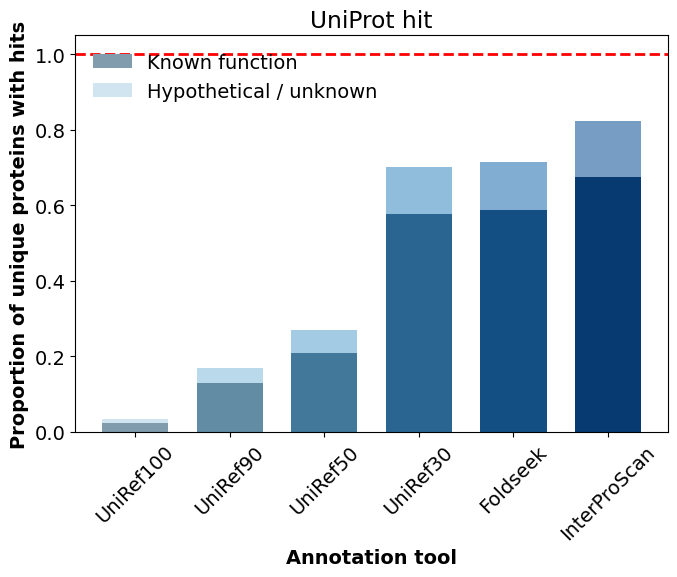

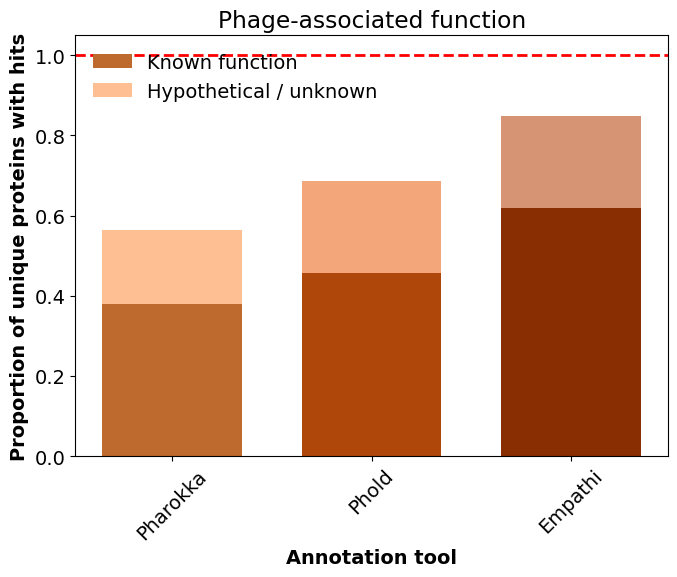

In [17]:
plt.rcParams.update({'font.size': 14})

# Known function for UniProt panel = also has phage/Empathi functional annotation
ann_plot = ann.with_columns(
    (
        (pl.col('pharokka_hit_type') == 'function')
        | (pl.col('phold_hit_type') == 'function')
        | pl.col('has_empathi')
    ).alias('has_known_function')
)

def method_known_hypo(mask: pl.Expr):
    sub = ann_plot.filter(mask)
    known = sub.filter(pl.col('has_known_function')).height
    hypo = sub.height - known
    return known, hypo

def stacked_cumulative_figure(methods, known_counts, hypo_counts, title, cmap_name):
    known_cum = np.cumsum(np.asarray(known_counts, dtype=float)) / total_proteins
    hypo_cum = np.cumsum(np.asarray(hypo_counts, dtype=float)) / total_proteins

    base = sns.color_palette(cmap_name, n_colors=len(methods) + 2)[2:]
    dark_colors = [tuple(np.clip(np.asarray(c, dtype=float) * 0.75, 0, 1)) for c in base]
    light_colors = [
        tuple(np.clip(np.asarray(c, dtype=float) + (1 - np.asarray(c, dtype=float)) * 0.45, 0, 1))
        for c in base
    ]

    x = np.arange(len(methods))
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.bar(x, known_cum, color=dark_colors, label='Known function', width=0.7)
    ax.bar(x, hypo_cum, bottom=known_cum, color=light_colors, label='Hypothetical / unknown', width=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(methods, rotation=45)
    ax.set_title(title)
    ax.set_xlabel('Annotation tool', fontweight='bold')
    ax.set_ylabel('Proportion of unique proteins with hits', fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.axhline(y=1.0, color='red', linestyle='--', linewidth=2)
    ax.legend(frameon=False, loc='upper left')
    plt.tight_layout()
    plt.show()

# UniProt / InterProScan cumulative order
uniprot_methods = ['UniRef100', 'UniRef90', 'UniRef50', 'UniRef30', 'Foldseek', 'InterProScan']
uniprot_known = []
uniprot_hypo = []
for method in uniprot_methods:
    if method.startswith('UniRef'):
        known, hypo = method_known_hypo(pl.col('uniprot_hit_level') == method)
    elif method == 'Foldseek':
        known, hypo = method_known_hypo(pl.col('has_foldseek'))
    else:
        known, hypo = method_known_hypo(pl.col('has_ips'))
    uniprot_known.append(known)
    uniprot_hypo.append(hypo)

stacked_cumulative_figure(
    uniprot_methods, uniprot_known, uniprot_hypo, 'UniProt hit', 'Blues'
)

# Phage-associated function: cumulative Pharokka -> Phold -> Empathi
# Empathi excludes all prior Pharokka/Phold hits (function + hypothetical)
phage_methods = ['Pharokka', 'Phold', 'Empathi']
phage_known = [n_pharokka_function, n_phold_function, n_empathi_exclusive]
phage_hypo = [n_pharokka_hypothetical, n_phold_hypothetical, 0]

stacked_cumulative_figure(
    phage_methods, phage_known, phage_hypo, 'Phage-associated function', 'Oranges'
)


In [18]:
## CARD hits from consolidated annotations
combined_card = ann.filter(pl.col('has_card')).select('hash').unique()
combined_card

hash
str
"""0b78e50688da61b5493e91e9768370…"
"""158e036ce73f8cafbf79625d54de4b…"
"""a53c22649c91afc92f58728d6c9e68…"
"""75edc63c04204f4422f800aef838ad…"
"""9b827cd7a3f4c5527ede1b32e0866e…"
…
"""fb00a48ee1ec81830f233d1109c77b…"
"""9efb9ec1ac58242e00e88f0342a856…"
"""c773f5da7c9bfc98122c9e5b339a13…"


In [19]:
## VFDB hits from consolidated annotations
combined_vfdb = ann.filter(pl.col('has_vfdb')).select('hash').unique()
combined_vfdb

hash
str
"""48a7de4c74e902cd09a8f044a36b88…"
"""0bd73d28a66b4f464e3cde9bdc48e1…"
"""67a203d1329d620713aa8684b09a14…"
"""fe741926f94a965952b57321773251…"
"""8eb812362522fbed1cac783b12c1c8…"
…
"""7a7362f5b6078fdb20e53ce08084f2…"
"""b65afc8c7fa3fb108d5640874b0396…"
"""cb9e810012c9a2f42f76e7849f1ec1…"


Total genomovar genomes: 508,370
shape: (3, 3)
┌─────────────────────────┬────────────┬───────┐
│ category                ┆ proportion ┆ count │
│ ---                     ┆ ---        ┆ ---   │
│ str                     ┆ f64        ┆ i64   │
╞═════════════════════════╪════════════╪═══════╡
│ ARG (CARD)              ┆ 0.000647   ┆ 329   │
│ Virulence factor (VFDB) ┆ 0.007717   ┆ 3923  │
│ ARG or VF               ┆ 0.008274   ┆ 4206  │
└─────────────────────────┴────────────┴───────┘


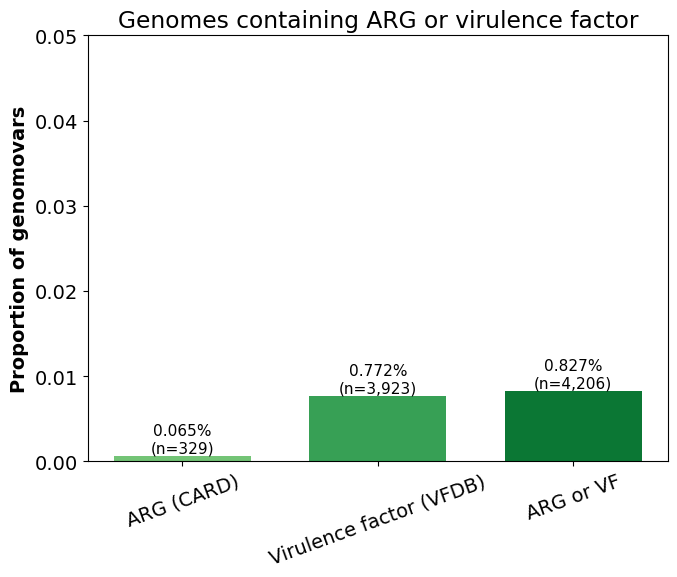

In [21]:
## Proportion of genomes with ARG (CARD) or virulence factor (VFDB)
genome_amr_vf = (
    pl.scan_csv(
        'uhvdb_r4_protein_annotations.tsv.gz',
        separator='\t',
        null_values=['', 'NA'],
    )
    .select(['genomovar_rep', 'card_acc', 'vfdb_acc'])
    .with_columns([
        (pl.col('card_acc').fill_null('').str.strip_chars() != '').alias('has_card'),
        (pl.col('vfdb_acc').fill_null('').str.strip_chars() != '').alias('has_vfdb'),
    ])
    .group_by('genomovar_rep')
    .agg([
        pl.col('has_card').any().alias('has_arg'),
        pl.col('has_vfdb').any().alias('has_vf'),
    ])
)

try:
    genome_amr_vf = genome_amr_vf.collect(engine='streaming')
except TypeError:
    genome_amr_vf = genome_amr_vf.collect(streaming=True)

genome_amr_vf = genome_amr_vf.with_columns(
    (pl.col('has_arg') | pl.col('has_vf')).alias('has_arg_or_vf')
)

n_genomes = genome_amr_vf.height
genome_props = pl.DataFrame({
    'category': ['ARG (CARD)', 'Virulence factor (VFDB)', 'ARG or VF'],
    'proportion': [
        genome_amr_vf['has_arg'].mean(),
        genome_amr_vf['has_vf'].mean(),
        genome_amr_vf['has_arg_or_vf'].mean(),
    ],
    'count': [
        int(genome_amr_vf['has_arg'].sum()),
        int(genome_amr_vf['has_vf'].sum()),
        int(genome_amr_vf['has_arg_or_vf'].sum()),
    ],
})
print(f'Total genomovar genomes: {n_genomes:,}')
print(genome_props)

plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(7, 6))
colors = sns.color_palette('Greens', n_colors=5)[2:]
ax.bar(
    genome_props['category'].to_list(),
    genome_props['proportion'].to_list(),
    color=colors,
    width=0.7,
)
ax.set_ylabel('Proportion of genomovars', fontweight='bold')
ax.set_xlabel('')
ax.set_title('Genomes containing ARG or virulence factor')
ax.set_ylim(0, max(0.05, float(genome_props['proportion'].max()) * 1.25))
ax.tick_params(axis='x', rotation=20)
for i, (prop, count) in enumerate(zip(genome_props['proportion'].to_list(), genome_props['count'].to_list())):
    ax.text(i, prop, f'{prop:.3%}\n(n={count:,})', ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()


Caudoviricetes genomovar representatives: 471,238
Caudoviricetes protein annotation rows: 32,668,838
shape: (9, 6)
┌────────────────────┬──────┬──────────────┬──────────────┬────────────────────┬───────────────────┐
│ Hallmark           ┆ step ┆ method_added ┆ method_label ┆ n_genomovars_singl ┆ prop_genomovars_s │
│ ---                ┆ ---  ┆ ---          ┆ ---          ┆ e_copy_cumul…      ┆ ingle_copy_cu…    │
│ str                ┆ i64  ┆ str          ┆ str          ┆ ---                ┆ ---               │
│                    ┆      ┆              ┆              ┆ i64                ┆ f64               │
╞════════════════════╪══════╪══════════════╪══════════════╪════════════════════╪═══════════════════╡
│ Major head protein ┆ 1    ┆ annot        ┆ Pharokka     ┆ 353774             ┆ 0.750733          │
│ Major head protein ┆ 2    ┆ product      ┆ Phold        ┆ 364890             ┆ 0.774322          │
│ Major head protein ┆ 3    ┆ Annotation   ┆ Empathi      ┆ 419605           

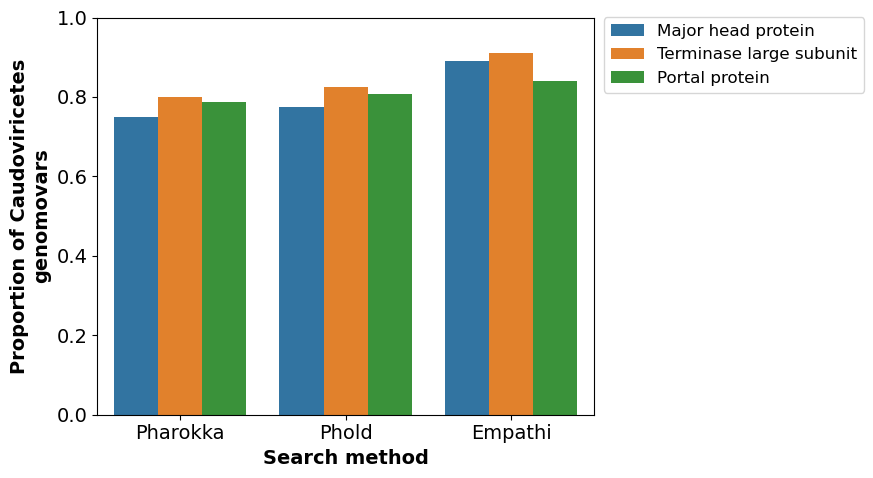

In [29]:
## Cumulative single-copy hallmarks in Caudoviricetes genomovars
# Mirrors figure_s11: Pharokka -> Phold -> Empathi cumulative coverage of
# single-copy major head / terminase large subunit / portal proteins.

caudo_genomovars = (
    pl.scan_csv(
        'uhvdb_r4_metadata.tsv.gz',
        separator='\t',
        null_values=['', 'NA'],
    )
    .filter(
        (pl.col('uhvdb_id') == pl.col('genomovar_rep'))
        & (pl.col('ictv_class') == 'Caudoviricetes')
    )
    .select(pl.col('uhvdb_id').alias('genomovar_rep'))
    .unique()
)

try:
    caudo_genomovars = caudo_genomovars.collect(engine='streaming')
except TypeError:
    caudo_genomovars = caudo_genomovars.collect(streaming=True)

n_caudo_genomovars = caudo_genomovars.height
print(f'Caudoviricetes genomovar representatives: {n_caudo_genomovars:,}')

caudo_ann_lf = (
    pl.scan_csv(
        'uhvdb_r4_protein_annotations.tsv.gz',
        separator='\t',
        null_values=['', 'NA'],
    )
    .select(['genomovar_rep', 'pharokka_annot', 'phold_annot', 'empathi_annot'])
    .join(caudo_genomovars.lazy(), on='genomovar_rep', how='semi')
    .rename({
        'pharokka_annot': 'annot',
        'phold_annot': 'product',
        'empathi_annot': 'Annotation',
    })
)

try:
    caudo_ann = caudo_ann_lf.collect(engine='streaming')
except TypeError:
    caudo_ann = caudo_ann_lf.collect(streaming=True)

print(f'Caudoviricetes protein annotation rows: {caudo_ann.height:,}')

method_order = ['annot', 'product', 'Annotation']
method_label_map = {
    'annot': 'Pharokka',
    'product': 'Phold',
    'Annotation': 'Empathi',
}

hallmark_method_filters = {
    'Major head protein': {
        'annot': pl.col('annot') == 'major head protein',
        'product': pl.col('product') == 'major head protein',
        'Annotation': pl.col('Annotation') == 'pvp|capsid|major_capsid',
    },
    'Terminase large subunit': {
        'annot': pl.col('annot') == 'terminase large subunit',
        'product': pl.col('product') == 'terminase large subunit',
        'Annotation': pl.col('Annotation') == 'DNA-associated|terminase|packaging_assembly',
    },
    'Portal protein': {
        'annot': pl.col('annot') == 'portal protein',
        'product': pl.col('product') == 'portal protein',
        'Annotation': pl.col('Annotation') == 'pvp|portal',
    },
}

cumulative_rows = []
for hallmark_label, per_method_filter in hallmark_method_filters.items():
    cumulative_ids = set()
    for i, method in enumerate(method_order, start=1):
        method_ids = set(
            caudo_ann
                .filter(per_method_filter[method])
                .group_by('genomovar_rep')
                .len()
                .filter(pl.col('len') == 1)
                ['genomovar_rep']
        )
        cumulative_ids.update(method_ids)
        cumulative_rows.append({
            'Hallmark': hallmark_label,
            'step': i,
            'method_added': method,
            'method_label': method_label_map[method],
            'n_genomovars_single_copy_cumulative': len(cumulative_ids),
        })

cumulative_single_copy = (
    pl.DataFrame(cumulative_rows)
        .with_columns(
            (pl.col('n_genomovars_single_copy_cumulative') / n_caudo_genomovars)
                .alias('prop_genomovars_single_copy_cumulative')
        )
)

print(cumulative_single_copy)

plt.rcParams.update({'font.size': 14})
plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=cumulative_single_copy.to_pandas(),
    x='method_label',
    y='prop_genomovars_single_copy_cumulative',
    hue='Hallmark',
)
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0, fontsize=12)
plt.xlabel('Search method', fontdict={'fontweight': 'bold'})
plt.ylabel('Proportion of Caudoviricetes\ngenomovars', fontdict={'fontweight': 'bold'})
# plt.title('Caudoviricetes single-copy hallmarks')
# plt.axhline(y=1.0, color='r', linestyle='--', linewidth=2)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [28]:
## Proportion of Caudoviricetes genomovars with >= 2 single-copy hallmarks
# Uses the final (Pharokka + Phold + Empathi) single-copy sets from the previous cell.

single_copy_by_hallmark = {}
for hallmark_label, per_method_filter in hallmark_method_filters.items():
    hallmark_ids = set()
    for method in method_order:
        method_ids = set(
            caudo_ann
                .filter(per_method_filter[method])
                .group_by('genomovar_rep')
                .len()
                .filter(pl.col('len') == 1)
                ['genomovar_rep']
        )
        hallmark_ids.update(method_ids)
    single_copy_by_hallmark[hallmark_label] = hallmark_ids
    print(f'{hallmark_label}: {len(hallmark_ids):,} genomovars with single-copy gene')

hallmark_counts = (
    caudo_genomovars
        .with_columns([
            pl.col('genomovar_rep').is_in(single_copy_by_hallmark['Major head protein']).alias('has_mcp'),
            pl.col('genomovar_rep').is_in(single_copy_by_hallmark['Terminase large subunit']).alias('has_terl'),
            pl.col('genomovar_rep').is_in(single_copy_by_hallmark['Portal protein']).alias('has_portal'),
        ])
        .with_columns(
            (
                pl.col('has_mcp').cast(pl.Int8)
                + pl.col('has_terl').cast(pl.Int8)
                + pl.col('has_portal').cast(pl.Int8)
            ).alias('n_single_copy_hallmarks')
        )
)

n_ge2 = hallmark_counts.filter(pl.col('n_single_copy_hallmarks') >= 2).height
prop_ge2 = n_ge2 / n_caudo_genomovars

summary = (
    hallmark_counts
        .group_by('n_single_copy_hallmarks')
        .len()
        .sort('n_single_copy_hallmarks')
        .with_columns(
            (pl.col('len') / n_caudo_genomovars).alias('proportion')
        )
)
print(summary)
print(f'Genomovars with >= 2 single-copy hallmarks: {n_ge2:,} / {n_caudo_genomovars:,} ({prop_ge2:.4%})')
prop_ge2


Major head protein: 419,605 genomovars with single-copy gene
Terminase large subunit: 429,611 genomovars with single-copy gene
Portal protein: 396,410 genomovars with single-copy gene
shape: (4, 3)
┌─────────────────────────┬────────┬────────────┐
│ n_single_copy_hallmarks ┆ len    ┆ proportion │
│ ---                     ┆ ---    ┆ ---        │
│ i8                      ┆ u32    ┆ f64        │
╞═════════════════════════╪════════╪════════════╡
│ 0                       ┆ 7223   ┆ 0.015328   │
│ 1                       ┆ 18982  ┆ 0.040281   │
│ 2                       ┆ 108455 ┆ 0.230149   │
│ 3                       ┆ 336578 ┆ 0.714242   │
└─────────────────────────┴────────┴────────────┘
Genomovars with >= 2 single-copy hallmarks: 445,033 / 471,238 (94.4391%)


0.9443911569100963